<p align="left">
  <a href="https://colab.research.google.com/github/wgomezf/ANNs/blob/main/Notebooks/CNN_scratch.ipynb" target="_parent">
    <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab" width="200">
  </a>
</p>

In [ ]:
#################################################
# Author: Wilfrido Gómez-Flores (Cinvestav)     #
# e-mail: wgomez@cinvestav.mx                   #
# Date:   february 2026                         #
# Subject: CNN for BUS classification           #
#################################################

# Change: Runtime to GPU
# Check GPU details
!nvidia-smi

# Libraries
import numpy as np                                                    # Numerical array operations
import matplotlib.pyplot as plt                                       # Data plotting/visualization
import tensorflow as tf                                               # Machine learning
import os                                                             # Interaction with the operating system
import gdown
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, BatchNormalization, Activation, MaxPooling2D, GlobalAveragePooling2D, Dense
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

Tue Mar 10 21:48:09 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA H100 80GB HBM3          Off |   00000000:04:00.0 Off |                    0 |
| N/A   37C    P0             68W /  700W |       0MiB /  81559MiB |      0%      Default |
|                                         |                        |             Disabled |
+-----------------------------------------+-----

In [ ]:
# Download BUS.zip dataset
!gdown --id 1BDIbNvvv7W2LYIIPD_SHgyy-J6nEbisy --output BUS.zip

# Unzip BUS.zip file
!unzip -q '/content/BUS.zip' -d '/content/'

# Remove BUS.zip file
!rm '/content/BUS.zip'

/usr/local/lib/python3.12/dist-packages/gdown/__main__.py:139: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From: https://drive.google.com/uc?id=1BDIbNvvv7W2LYIIPD_SHgyy-J6nEbisy
To: /content/BUS.zip
100% 16.1M/16.1M [00:00<00:00, 289MB/s]


Training images



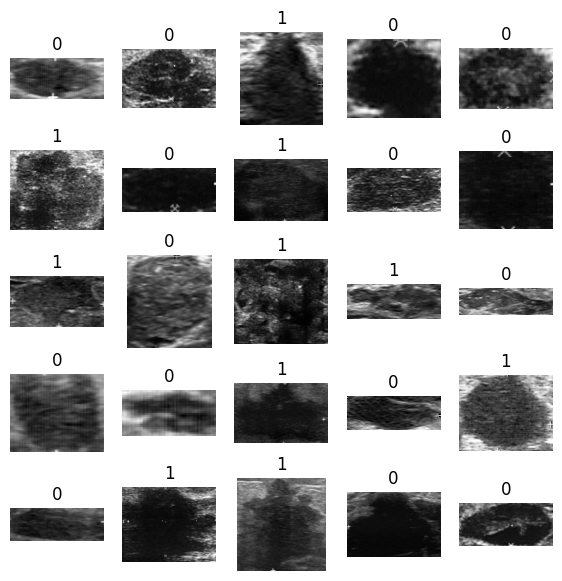

In [ ]:
# Paths
dataset = 'BUS'
path = '/content/' + dataset + '/'

train_dir = path + 'train/'
val_dir = path + 'valid/'
test_dir = path + 'test/'

# Data visualization
ncols = 5
nrows = 5

folders = os.listdir(train_dir)
pictures = []
clas = []

# Concatenating images
for folder in folders:
  pictures += [train_dir + folder + '/' + name for name in os.listdir(train_dir + folder)]
  clas += [folder for name in os.listdir(train_dir + folder)]

# Shuffle data
ind = np.random.permutation(len(clas))
pictures = np.array(pictures)[ind]
clas = np.array(clas)[ind]

# Create figure
fig, axs = plt.subplots(figsize=(7, 7))
plt.axis('off')

print('Training images\n')

for i in range(ncols * nrows):

  axs = fig.add_subplot(nrows, ncols, i + 1)
  img = plt.imread(pictures[i])
  axs.imshow(img, cmap='gray')
  axs.axis('off')

  label = str(clas[i])
  plt.title(label)

plt.show()

Found 1313 images belonging to 2 classes.
Found 281 images belonging to 2 classes.
Found 281 images belonging to 2 classes.


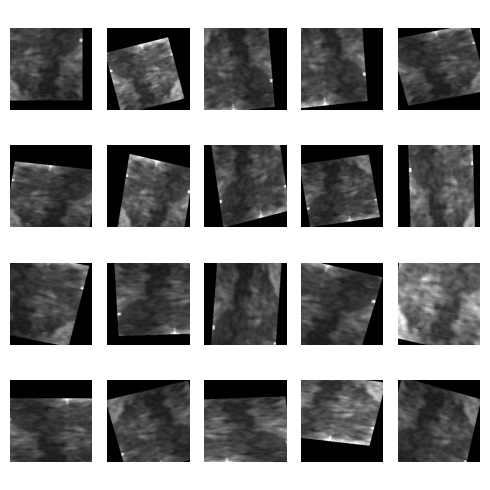

In [ ]:
# Prepare training, validation, and test sets
class_mode = 'binary'
batch_size = 32
image_size =  (224, 224)
image_mode = 'grayscale'

# Batch generation
data_augmentation = True

# Artificial data augmentation only in training set
if data_augmentation:
  train_datagen = ImageDataGenerator(rescale=1.0/255.0,
                                     zoom_range=0.3,
                                     rotation_range=15,
                                     width_shift_range=0.2,
                                     height_shift_range=0.2,
                                     horizontal_flip=True,
                                     vertical_flip=True,
                                     brightness_range=[0.5, 1.5],
                                     fill_mode='constant')
else:
  train_datagen = ImageDataGenerator(rescale=1.0/255.0)

val_datagen = ImageDataGenerator(rescale = 1.0/255.0)
test_datagen = ImageDataGenerator(rescale = 1.0/255.0)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size = image_size,
    batch_size = batch_size,
    color_mode = image_mode,
    class_mode = class_mode,
    shuffle = True)

val_generator = val_datagen.flow_from_directory(
    val_dir,
    target_size = image_size,
    batch_size = batch_size,
    color_mode = image_mode,
    class_mode = class_mode,
    shuffle = False)

test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size = image_size,
    batch_size = batch_size,
    color_mode = image_mode,
    class_mode = class_mode,
    shuffle = False)

# Visualize augmented data
def plottingImages(images):
    plt.subplots(figsize = (5, 5))
    cols = 5
    rows = len(images) // cols
    plt.axis('off')

    for c, img in enumerate(images):
        plt.subplot(rows, cols, c + 1)
        plt.imshow(img, cmap = 'gray')
        plt.axis('off')

    plt.tight_layout()
    plt.show()

augmented_images = [train_generator[0][0][0] for i in range(20)]
plottingImages(augmented_images)

In [ ]:
# CNN model based on the architecture in https://doi.org/10.1109/ACCESS.2020.3010863
model = Sequential()

# First convolutional and pooling layer
model.add(Conv2D(64, (3, 3), input_shape=(224, 224, 1), padding='same', activation=None))
model.add(BatchNormalization())
model.add(Activation('relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))

# Second convolutional and pooling layer
model.add(Conv2D(128, (3, 3), padding='same', activation=None))
model.add(BatchNormalization())
model.add(Activation('relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))

# Third convolutional and pooling layer
model.add(Conv2D(256, (3, 3), padding='same', activation=None))
model.add(BatchNormalization())
model.add(Activation('relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))

# Fourth convolutional and pooling layer
model.add(Conv2D(512, (3, 3), padding='same', activation=None))
model.add(BatchNormalization())
model.add(Activation('relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))

# Fifth convolutional and pooling layer
model.add(Conv2D(1024, (3, 3), padding='same', activation=None))
model.add(BatchNormalization())
model.add(Activation('relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))

# Output layer
model.add(GlobalAveragePooling2D())
model.add(Dense(units=1, activation='sigmoid'))

# Model description
print('Model summary\n\n')
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model summary




Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 224, 224, 64)   │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 224, 224, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 224, 224, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 112, 112, 128)  │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 112, 112, 128)  │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 56, 56, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 56, 56, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 28, 28, 512)    │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 28, 28, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 14, 14, 1024)   │     4,719,616 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 14, 14, 1024)   │         4,096 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 14, 14, 1024)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 7, 7, 1024)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1024)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │         1,02

 Total params: 6,278,401 (23.95 MB)

 Trainable params: 6,274,433 (23.94 MB)

 Non-trainable params: 3,968 (15.50 KB)

In [ ]:
# Compile model
adam = tf.keras.optimizers.Adam(learning_rate=1e-3)
model.compile(loss='binary_crossentropy', optimizer=adam, metrics=['auc'])

# Callbacks
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_auc',
    patience=10,
    mode='max',
    restore_best_weights=True
) # Early stopping

reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_auc',
    factor=0.5,
    patience=5,
    min_lr=1e-6,
    verbose=1
) # Learning rate schedule

# Train model
epochs = 100
history = model.fit(train_generator,
                    batch_size=batch_size,
                    epochs=epochs,
                    validation_data=(val_generator),
                    verbose=1,
                    callbacks=[early_stop, reduce_lr])

Epoch 1/100


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


42/42 ━━━━━━━━━━━━━━━━━━━━ 18s 201ms/step - auc: 0.4918 - loss: 1.3553 - val_auc: 0.5226 - val_loss: 0.9172 - learning_rate: 0.0010
Epoch 2/100
42/42 ━━━━━━━━━━━━━━━━━━━━ 3s 81ms/step - auc: 0.5900 - loss: 0.6419 - val_auc: 0.5158 - val_loss: 0.6153 - learning_rate: 0.0010
Epoch 3/100
42/42 ━━━━━━━━━━━━━━━━━━━━ 4s 84ms/step - auc: 0.6004 - loss: 0.6399 - val_auc: 0.5309 - val_loss: 0.6180 - learning_rate: 0.0010
Epoch 4/100
42/42 ━━━━━━━━━━━━━━━━━━━━ 3s 81ms/step - auc: 0.6587 - loss: 0.6183 - val_auc: 0.5296 - val_loss: 0.7203 - learning_rate: 0.0010
Epoch 5/100
42/42 ━━━━━━━━━━━━━━━━━━━━ 3s 80ms/step - auc: 0.7295 - loss: 0.5803 - val_auc: 0.5324 - val_loss: 1.2641 - learning_rate: 0.0010
Epoch 6/100
42/42 ━━━━━━━━━━━━━━━━━━━━ 3s 81ms/step - auc: 0.6891 - loss: 0.5673 - val_auc: 0.6372 - val_loss: 0.7148 - learning_rate: 0.0010
Epoch 7/100
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step - auc: 0.7451 - loss: 0.5399
Epoch 7: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
4

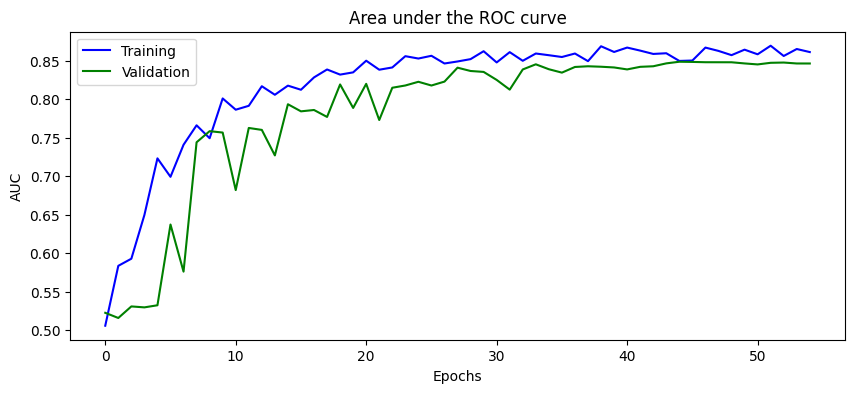

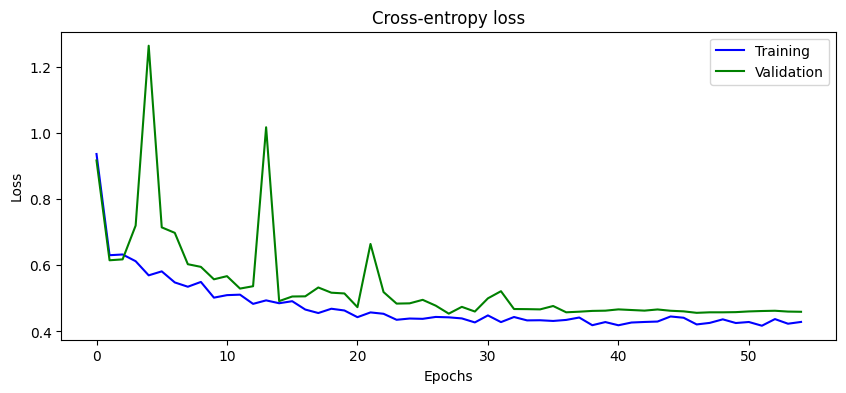

In [ ]:
# Training and validation graphs
training_acc = history.history['auc']
validation_acc = history.history['val_auc']
training_loss = history.history['loss']
validation_loss = history.history['val_loss']
epocas = np.arange(len(training_loss))

plt.figure(figsize=(10, 4))
plt.plot(epocas, training_acc, color='blue', label='Training')
plt.plot(epocas, validation_acc, color = 'green', label='Validation')
plt.title('Area under the ROC curve')
plt.xlabel('Epochs')
plt.ylabel('AUC')
plt.legend()
plt.show()
print()

plt.figure(figsize = (10, 4))
plt.plot(epocas, training_loss, color='blue', label='Training')
plt.plot(epocas, validation_loss, color = 'green', label='Validation')
plt.title('Cross-entropy loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

{0: '0', 1: '1'}
Test images



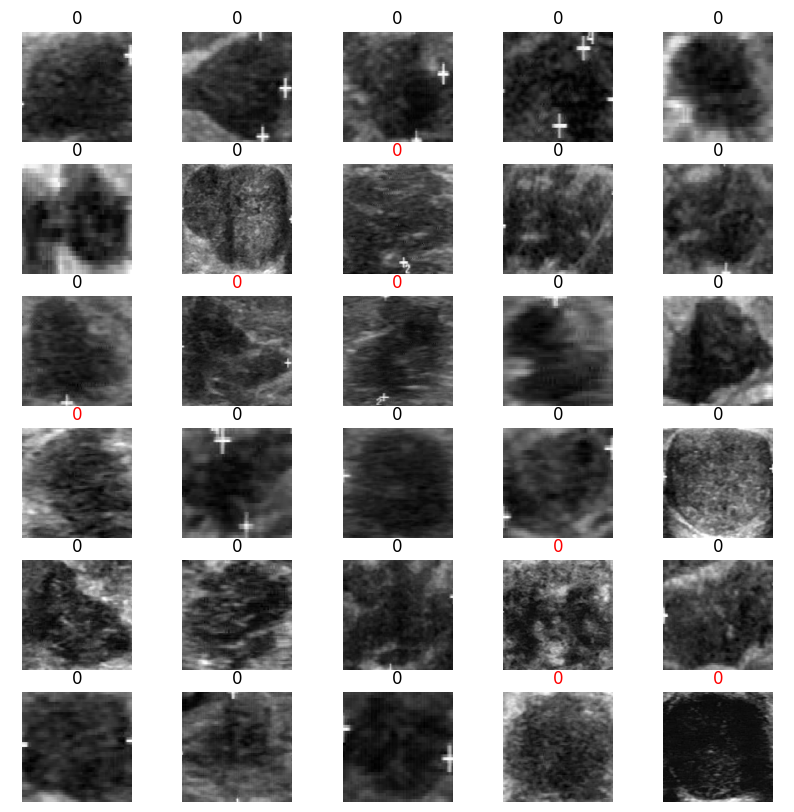

In [ ]:
# Predict a batch
batch = next(test_generator)
images = batch[0]
targets = batch[1]

results = model.predict(images, verbose = 0)
results = np.round(results)

# Indexing classes
dict_classes = test_generator.class_indices
dict_classes = {v:k for k, v in dict_classes.items()}
print(dict_classes)

# Data visualization
ncols = 5
nrows = 6

# Create figure
fig, axs = plt.subplots(figsize=(10, 10))
plt.axis('off')

print('Test images\n')
for i in range(ncols * nrows):
  axs = fig.add_subplot(nrows, ncols, i + 1)
  axs.imshow(images[i], cmap='gray')
  axs.axis('off')
  label = str(dict_classes[targets[i]])
  if targets[i] != results[i]:
    plt.title(label, color='red')
  else:
    plt.title(label)
plt.show()

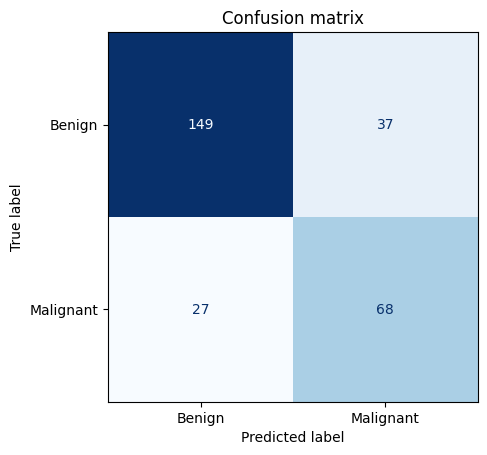

Accuracy: 0.772 

Sensitivity: 0.716 

Specificity: 0.801 



In [ ]:
# Get true labels and predictions from test set
test_generator.reset()
Y_true  = test_generator.labels
Y_true  = Y_true.reshape(-1, 1)
Y_probs = model.predict(test_generator, verbose = 0)
Y_pred  = np.round(Y_probs)

# Confusion matrix
cm = confusion_matrix(Y_true, Y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Benign', 'Malignant'])
disp.plot(colorbar=False, cmap='Blues')
plt.title('Confusion matrix')
plt.show()

# Performance indices
tn, fp, fn, tp = confusion_matrix(Y_true, Y_pred).ravel()
acc = (tp + tn) / (tp + tn + fp + fn)
sen = tp / (tp + fn)
spe = tn / (tn + fp)
print(f"Accuracy: {acc:.3f} \n")
print(f"Sensitivity: {sen:.3f} \n")
print(f"Specificity: {spe:.3f} \n")

In [ ]:
# Uncomment these lines to perform the following tasks:
# 1. Save CNN model i Google drive
# from google.colab import drive
# drive.mount('/content/drive')
# model.save('/content/drive/MyDrive/bus_cnn.keras')
# # 2. Import CNN model from Google drive
# model_path = '/content/drive/MyDrive/bus_cnn.keras'
# loaded_model = tf.keras.models.load_model(model_path)
# loaded_model.summary()